# **ResNet-50 (Configuration 1)** 

This configuration serves as the baseline model, using a standard Softmax classifier, simple image resizing, balanced class weights, and a single-phase training strategy where all layers are trainable from the start.

**1. Model Architecture & Output**
*   **Classifier Head**: The top of the pre-trained ResNet-50 is replaced with a custom network: `Global Average Pooling (GAP) -> Dropout(0.2) -> Dense(5)`. 
    *   *GAP* flattens the spatial features efficiently. 
    *   *Dropout(0.2)* provides light penalization against overfitting.
*   **Output Formulation & Thresholding**: The final layer uses **Softmax** to output probabilities across **5 mutually exclusive classes** (KL grades 0-4). The final prediction takes the class with the highest probability (**argmax**), without custom thresholds.

**2. Data Pipeline**
*   **Preprocessing & Augmentation**: The pipeline is kept extremely basic. Images are simply resized to **224x224**. No contrast enhancement or data augmentation is applied.
*   **Class Weights**: Set to **Balanced (sklearn)** to handle class imbalance explicitly during training.

**3. Single-Phase Training Strategy**
The model is trained using **Categorical Cross-Entropy** (standard for multi-class tasks) in a single distinct phase:
*   **Phase 1 (Full Training)**: All layers of the ResNet-50 backbone are trainable from the start. It uses the **Adam optimizer** with a default learning rate of **1e-3 (0.001)**. Training is monitored with an **Early Stopping Patience of 7**.

### Model Configuration

| Parameter | Configuration 1 |
| :--- | :--- |
| **Output Formulation** | Softmax (5-class) |
| **Loss Function** | Categorical Cross-Entropy |
| **Preprocessing** | Simple resize 224×224 |
| **Optimizer** | Adam (LR=1e-3) |
| **Training Strategy** | Single-phase, all layers trainable |
| **Class Weights** | Balanced (sklearn) |
| **Classifier Head** | GAP → Dropout(0.2) → Dense(5) |
| **L2 Regularization** | None |
| **Early Stopping** | Patience = 7 |


In [1]:
import sys
print(sys.executable)

/workspaces/fyp_experiment/.venv-4/bin/python


In [2]:
import tensorflow as tf

# Keep the GPU available and enable memory growth so TensorFlow does not
# reserve all device memory up front inside the container.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f"Could not enable memory growth for {gpu}: {exc}")

print("TF version:", tf.__version__)
print("GPUs:", gpus)

I0000 00:00:1780645817.321892    2400 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1780645821.551536    2400 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Environment Setup

First, let's import all the necessary libraries for data handling, visualization, and deep learning model building.

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import timeit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix)
import cv2

np.random.seed(12049)

### Seed Configuration
Setting a fixed random seed ensures reproducibility of results across different runs.

In [5]:
def get_classes(data_path, classes, data):
    print(f"----{data}----")
    knee_severity={}
    count=0

    for i in range(len(classes)):
        imgs=os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i]=imgs
        count+=len(imgs)

    for k, v in knee_severity.items():
        print(
            f"Grade {k}-{classes[k]}: {len(v)} images, {round((len(v)*100)/count, 2)}%"
        )

    return knee_severity

def plot_classes(dict_classes, data_path, classes, data):
    for k, v in dict_classes.items():
        print(f"{data}-{classes[k]}")
        plt.figure(figsize=(10, 25))
        for i in range(5):
            img_path=os.path.join(data_path, str(k), v[i])
            img=tf.keras.preprocessing.image.load_img(img_path)
            plt.subplot(1, 5, 1+i, xticks=[], yticks=[])
            plt.imshow(img)
            plt.title(f"Grade {k}")
        plt.show()

### Helper Functions
These utility functions will be used throughout the notebook for:
- Loading and analyzing dataset statistics
- Visualizing sample images from each class
- Computing metrics and training curves

In [ ]:
# ==============================================================================
# METRIC HELPER FUNCTIONS  (Comprehensive Evaluation Metrics Matrix)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc, f1_score,
    cohen_kappa_score, mean_absolute_error as sk_mae,
)
from sklearn.preprocessing import label_binarize

def _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes):
    """Macro ROC AUC using ordinal score matrix: P(Y >= k)"""
    ordinal_scores = np.zeros((len(y_true_bin), n_classes - 1))
    for k in range(1, n_classes):
        ordinal_scores[:, k - 1] = np.sum(y_pred_probs[:, k:], axis=1)

    y_true_ord = np.argmax(y_true_bin, axis=1)
    pair_aucs = []
    for k in range(1, n_classes):
        binary_labels = (y_true_ord >= k).astype(int)
        if len(np.unique(binary_labels)) > 1:
            try:
                auc_k = roc_auc_score(binary_labels, ordinal_scores[:, k - 1])
                pair_aucs.append(auc_k)
            except Exception:
                pass
    return float(np.mean(pair_aucs)) if pair_aucs else float('nan')


def comprehensive_evaluation_metrics_matrix(y_true, y_pred_probs, split_name, class_names, model_name):
    """
    Compute and display the full Comprehensive Evaluation Metrics Matrix for one split.
    """
    y_true        = np.asarray(y_true)
    y_pred_probs  = np.asarray(y_pred_probs)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    n_classes     = len(class_names)
    y_true_bin    = label_binarize(y_true, classes=range(n_classes))

    accuracy         = accuracy_score(y_true, y_pred_labels)
    bal_accuracy     = balanced_accuracy_score(y_true, y_pred_labels)
    mae              = sk_mae(y_true, y_pred_labels)
    macro_auc_ord    = _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes)
    try:
        weighted_auc = roc_auc_score(y_true_bin, y_pred_probs,
                                     multi_class='ovr', average='weighted')
    except Exception:
        weighted_auc = float('nan')
    qwk = cohen_kappa_score(y_true, y_pred_labels, weights='quadratic')

    sep  = '─' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<40} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<40} {accuracy:>10.4f}')
    print(f'  {"Balanced Accuracy":<40} {bal_accuracy:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<40} {mae:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<40} {macro_auc_ord:>10.4f}')
    print(f'  {"Weighted ROC AUC":<40} {weighted_auc:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<40} {qwk:>10.4f}')
    print(f'{sep}')

    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred_labels, labels=range(n_classes), zero_division=0
    )
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for idx, cname in enumerate(class_names):
        print(f'  {cname:<14} {prec[idx]:>10.4f} {rec[idx]:>10.4f} {f1[idx]:>10.4f} {int(sup[idx]):>10}')
    print(f'  {sep2}')

    metrics_dict = {
        'Split':                    split_name,
        'Overall Accuracy':         round(accuracy,      4),
        'Balanced Accuracy':        round(bal_accuracy,  4),
        'MAE':                      round(mae,           4),
        'Macro ROC AUC (ordinal)':  round(macro_auc_ord, 4),
        'Weighted ROC AUC':         round(weighted_auc,  4),
        'Quadratic Weighted Kappa': round(qwk,           4),
    }
    csv_path = f'metrics_{split_name.lower().replace(" ", "_")}.csv'
    pd.DataFrame([metrics_dict]).to_csv(csv_path, index=False)
    print(f'\n  Saved metrics to: {csv_path}')
    print(f'{sep}\n')
    return metrics_dict

class_names=['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

def plot_confusion_matrix(ytrue_labels, ypred_probs, class_names, model_name, normalize=True):
    """Plot confusion matrix."""
    y_true  = np.asarray(ytrue_labels)
    y_pred  = np.argmax(np.asarray(ypred_probs), axis=1)
    cm_raw  = confusion_matrix(y_true=y_true, y_pred=y_pred)
    if normalize:
        cm_plot = cm_raw.astype('float') / np.maximum(cm_raw.sum(axis=1, keepdims=True), 1)
        fmt, cmap = '.2f', 'Purples'
    else:
        cm_plot, fmt, cmap = cm_raw, 'd', 'YlOrRd'
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    suffix = '(Normalised)' if normalize else '(Counts)'
    plt.title(f'Confusion Matrix {suffix} - {model_name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show(block=False)


def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    """Plot per-class OvR ROC curves."""
    n_classes  = len(class_names)
    y_true_bin = label_binarize(np.asarray(y_true), classes=range(n_classes))
    plt.figure(figsize=(12, 8))
    for idx in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], np.asarray(y_pred_probs)[:, idx])
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[idx]} (AUC = {auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title(f'ROC Curves (OvR) - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def plot_f1_per_class(y_true, y_pred_labels, class_names, model_name):
    """Bar chart of per-class macro F1 scores."""
    scores = f1_score(np.asarray(y_true), np.asarray(y_pred_labels),
                      labels=range(len(class_names)), average=None, zero_division=0)
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, scores, color=colors, edgecolor='black', linewidth=1.2)
    for bar, s in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width() / 2, s + 0.01,
                 f'{s:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('KL Grade', fontsize=12, fontweight='bold')
    plt.title(f'Per-Class F1 Score - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1]); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def get_evaluate(data, name, model):
    score = model.evaluate(data, verbose=1)
    print(f'{name} loss: {score[0]:.4f}  |  {name} accuracy: {score[1]:.4f}')

def get_predict(data, model):
    return model.predict(data, verbose=1)

print("Metric helper functions defined.")


Metric helper functions defined.


### Model Evaluation Functions
These functions help us visualize training progress and evaluate model performance through various metrics.

In [7]:
### COMPREHENSIVE METRICS FUNCTIONS

def compute_comprehensive_metrics(y_true, y_pred_probs, y_pred_labels, class_names, model_name):
    """
    Comprehensive evaluation: accuracy, precision, recall, F1, and ROC AUC
    """
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    
    print("\n" + "=" * 80)
    print(f"COMPREHENSIVE EVALUATION - {model_name}")
    print("=" * 80)
    
    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    
    print(f"\n📊 OVERALL ACCURACY:")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Balanced Accuracy: {bal_acc:.4f}")
    
    print(f"\n📈 DETAILED CLASSIFICATION REPORT (Precision/Recall/F1):")
    print(classification_report(y_true, y_pred_labels, target_names=class_names, digits=4))
    
    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        roc_auc_macro = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='macro')
        roc_auc_weighted = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='weighted')
        
        print(f"\n🎯 ROC AUC SCORES:")
        print(f"   ROC AUC (Macro): {roc_auc_macro:.4f}")
        print(f"   ROC AUC (Weighted): {roc_auc_weighted:.4f}")
    except Exception as e:
        print(f"\n⚠️  ROC AUC note: {str(e)}")

def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    """Plot ROC curves for each class (One-vs-Rest)"""
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    plt.figure(figsize=(12, 8))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_f1_scores_per_class(y_true, y_pred_labels, class_names, model_name):
    """Visualize F1 scores for each class"""
    from sklearn.metrics import f1_score
    
    f1_scores = []
    for i in range(len(class_names)):
        f1 = f1_score(y_true, y_pred_labels, labels=[i], average='weighted', zero_division=0)
        f1_scores.append(f1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('Osteoarthritis Grade', fontsize=12, fontweight='bold')
    plt.title(f'F1 Score Distribution - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2. Dataset Configuration

### Class Definitions
The model classifies knee osteoarthritis into five severity grades based on radiographic evidence.

In [9]:
# Using train_balanced dataset for better class balance
base_dir="/workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis"
train_path=os.path.join(base_dir, 'train_balanced')
valid_path=os.path.join(base_dir, 'val')
test_path=os.path.join(base_dir, 'test')

print(f"Train path: {train_path}")
print(f"Valid path: {valid_path}")
print(f"Test path: {test_path}")

Train path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
Valid path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
Test path: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test


### Data Paths
The balanced dataset is split into three subsets: training (balanced), validation, and test. The balanced training set ensures equal representation across all severity classes.

In [10]:
train_data=get_classes(train_path, class_names, 'train_balanced')
valid_data=get_classes(valid_path, class_names, 'Valid')
test_data=get_classes(test_path, class_names, 'Test')

----train_balanced----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


### Dataset Analysis
Let's examine the class distribution and visualize sample images from each category to understand the data we're working with.

Train data (Balanced)-Healthy


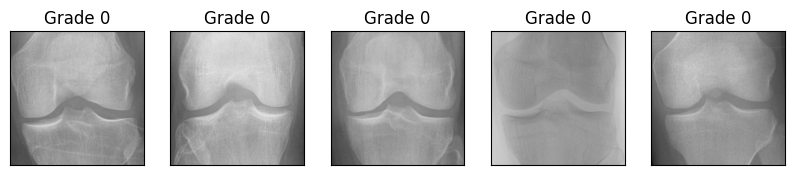

Train data (Balanced)-Doubtful


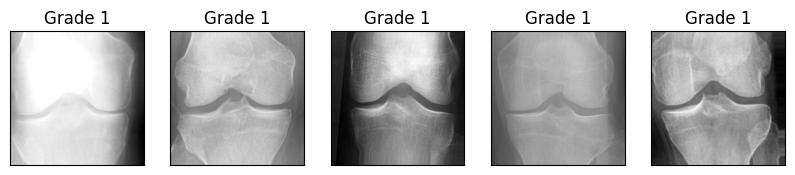

Train data (Balanced)-Minimal


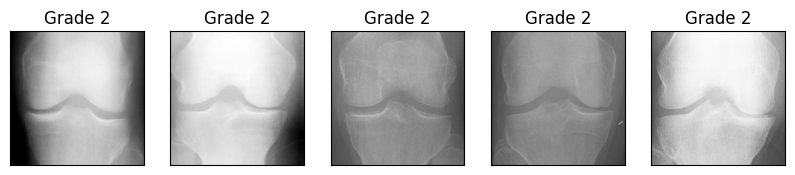

Train data (Balanced)-Moderate


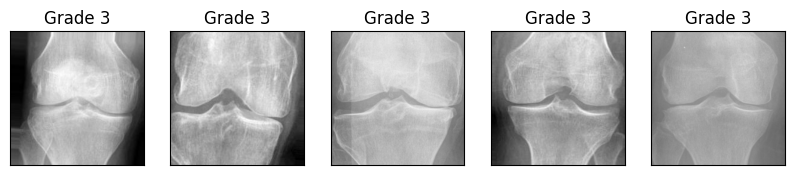

Train data (Balanced)-Severe


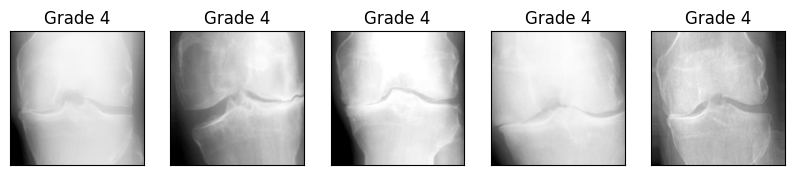

In [11]:
plot_classes(train_data, train_path, class_names, 'Train data (Balanced)')

Displaying sample images from the balanced training set to verify data quality.

## 3. Model Configuration

### Training Parameters
Define all hyperparameters and paths for the ResNet50 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
model_config = {
    'model_name': 'ResNet50-Baseline',
    'target_size': (224, 224),
    'epochs': 50,
    'batch_size': 16,
    'img_shape': (224, 224, 3),
}

target_size = model_config['target_size']
epochs = model_config['epochs']
batch_size = model_config['batch_size']
img_shape = model_config['img_shape']
model_name = model_config['model_name']

# Create models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

save_model_ft = os.path.join('models', f'model_{model_name}_ft.keras')

ts = globals().get("target_size", (224, 224))

aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
)
noaug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
)

train_generator = aug_datagen.flow_from_directory(
    train_path, class_mode="categorical", target_size=ts, batch_size=batch_size, shuffle=True
)

valid_generator = noaug_datagen.flow_from_directory(
    valid_path,
    class_mode="categorical",
    target_size=ts,
    batch_size=batch_size,
    shuffle=False,
)

Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.


### Loading Data into Generators
The generators load images in batches, resize them to 224×224 pixels, and apply CLAHE preprocessing for enhanced contrast.

In [15]:
y_train = train_generator.labels
y_val = valid_generator.labels

## 4. Class Balance & Weights

### Computing Class Weights
Even with a balanced dataset, we compute class weights to emphasize underrepresented classes during training. This ensures the model learns equally from all severity grades.

In [16]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train: ", dict(zip(unique, counts)))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

Train:  {0: 2246, 1: 2245, 2: 2245, 3: 2245, 4: 2245}
{0: 0.9996438112199466, 1: 1.0000890868596881, 2: 1.0000890868596881, 3: 1.0000890868596881, 4: 1.0000890868596881}


## 5. Model Architecture

### Building the EfficientNet-V2B3 (C1) Model

Transfer learning is applied by loading a pre-trained **EfficientNet-V2B3** model with **ImageNet weights**. 
All backbone layers are unfrozen from the start, allowing the entire network to adapt to the knee X-ray 
domain in a single training phase.

The classification head consists of:

| Layer | Description |
|---|---|
| **Global Average Pooling** | Reduces the 7×7×1536 feature maps to a 1536-dimensional vector |
| **Dropout (0.2)** | Randomly disables 20% of neurons during training to reduce overfitting |
| **Dense (5, Softmax)** | Outputs probability distribution across the five KL severity grades |

The model is compiled with the following settings:

- **Optimizer:** Adam (default learning rate)
- **Loss Function:** Categorical Cross-Entropy
- **Class Weights:** Balanced, to compensate for uneven grade distribution in the training set
- **Early Stopping:** Patience = 7, monitoring validation loss to prevent overfitting

In [ ]:
model = tf.keras.applications.resnet50.ResNet50(
    input_shape=img_shape,
    include_top=False,
    weights="imagenet",
)

for layer in model.layers:
    layer.trainable = True

model_ft = tf.keras.models.Sequential(
    [
        model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(5, activation="softmax"),
    ]
)

model_ft.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 5)                 10245     
                                                                 
Total params: 23597957 (90.02 MB)
Trainable params: 23544837 (89.82 MB)
Non-trainable params: 53120 (207.50 KB)
_________________________________________________________________


## 6. Training & Fine-tuning Strategy
All base model layers are made trainable to adapt the pre-trained features to our specific medical imaging task. The model is compiled with Adam optimizer and categorical crossentropy loss.
The model trains for 20 epochs using the balanced training generator with class weights. Validation performance is monitored on a separate validation set.

In [19]:
model_ft.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_model_ft,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

start_ft = timeit.default_timer()

history = model_ft.fit(
    train_generator,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=valid_generator,
    class_weight=train_class_weights,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1,
)

stop_ft = timeit.default_timer()


Epoch 1/50


I0000 00:00:1780645828.551329    2400 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780645864.517167    2628 cuda_dnn.cc:461] Loaded cuDNN version 90701
W0000 00:00:1780645870.868406    2628 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
I0000 00:00:1780645902.606401    2629 service.cc:153] XLA service 0x739ab6684890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780645902.606451    2629 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Com

702/702 [==============================] - ETA: 0s - loss: 1.1343 - accuracy: 0.5095
Epoch 1: val_loss improved from inf to 3.17276, saving model to models/model_ResNet50-Baseline_ft.keras
702/702 [==============================] - 209s 154ms/step - loss: 1.1343 - accuracy: 0.5095 - val_loss: 3.1728 - val_accuracy: 0.2518
Epoch 2/50
702/702 [==============================] - ETA: 0s - loss: 0.8469 - accuracy: 0.6484
Epoch 2: val_loss improved from 3.17276 to 1.31598, saving model to models/model_ResNet50-Baseline_ft.keras
702/702 [==============================] - 101s 144ms/step - loss: 0.8469 - accuracy: 0.6484 - val_loss: 1.3160 - val_accuracy: 0.4322
Epoch 3/50
702/702 [==============================] - ETA: 0s - loss: 0.7592 - accuracy: 0.6867
Epoch 3: val_loss improved from 1.31598 to 1.18058, saving model to models/model_ResNet50-Baseline_ft.keras
702/702 [==============================] - 101s 143ms/step - loss: 0.7592 - accuracy: 0.6867 - val_loss: 1.1806 - val_accuracy: 0.538

In [20]:
execution_time_ft = (stop_ft - start_ft) / 60
print(
    f"Model {model_name} fine tuning executed in {execution_time_ft:.2f} minutes"
)

Model ResNet50-Baseline fine tuning executed in 24.18 minutes


In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv('train_history.csv', index=False)

with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump(history.history, f, indent=2)

print('Saved train_history.csv and train_history.json')

Saved train_history.csv and train_history.json


In [22]:
model_ft.save(save_model_ft)
print(f"Model saved to {save_model_ft}")

Model saved to models/model_ResNet50-Baseline_ft.keras


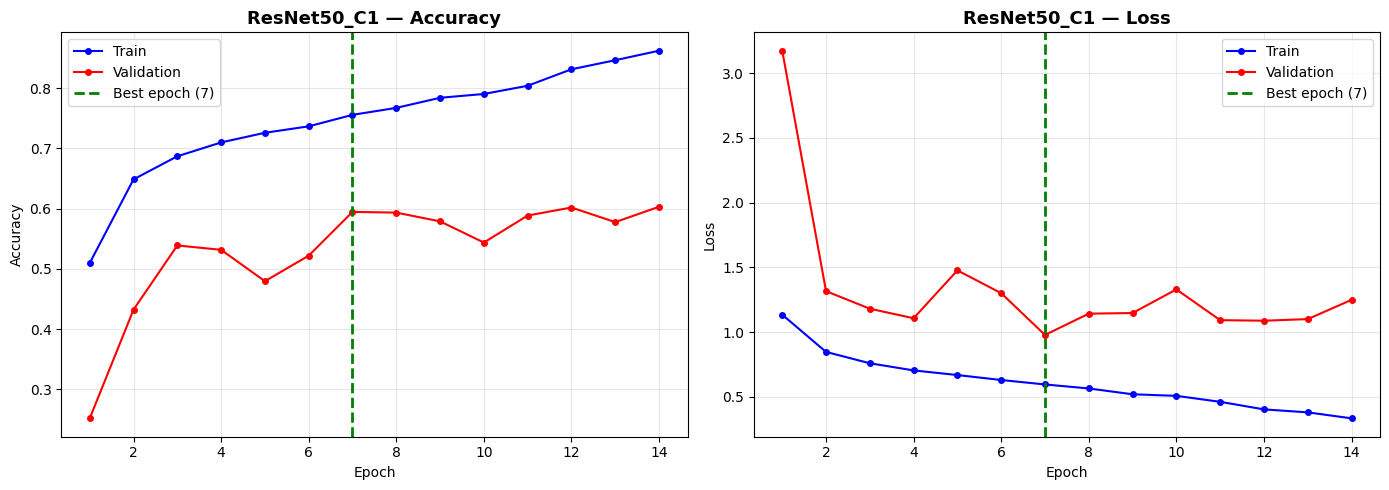

Total epochs: 14
Best epoch: 7 (lowest val_loss: 0.9779)
Best val_accuracy: 0.5944


In [1]:
# ── Training History Visualization ────────────────────────────────────────────
import json
from pathlib import Path
import matplotlib.pyplot as plt
MODEL_NAME = "ResNet50_C1"

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'

with open(report_dir / 'train_history.json', 'r', encoding='utf-8') as f:
    raw_history = json.load(f)

# Handle phased training (phase1 + phase2) vs flat history
if 'phase1' in raw_history:
    history = {}
    for key in raw_history['phase1']:
        history[key] = raw_history['phase1'][key] + raw_history['phase2'][key]
else:
    history = raw_history

epochs = range(1, len(history['loss']) + 1)

# Ordinal regression logs MAE as training objective; classification logs accuracy
is_ordinal = 'mae' in history

# Best epoch = lowest val_loss (what ModelCheckpoint saved)
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if is_ordinal:
    ax1.plot(epochs, history['mae'], 'b-o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_mae'], 'r-o', markersize=4, label='Validation')
    ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
    ax1.set_ylabel('MAE')
else:
    ax1.plot(epochs, history['accuracy'], 'b-o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_accuracy'], 'r-o', markersize=4, label='Validation')
    ax1.set_title(f'{MODEL_NAME} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Accuracy')

ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f'Total epochs: {len(history["loss"])}')
print(f'Best epoch: {best_epoch} (lowest val_loss: {min(history["val_loss"]):.4f})')
if is_ordinal:
    print(f'Best val_mae: {history["val_mae"][best_epoch - 1]:.4f}')
else:
    print(f'Best val_accuracy: {history["val_accuracy"][best_epoch - 1]:.4f}')


### Training History Visualization
Visualizing loss and accuracy curves across training and validation sets to assess model convergence and detect overfitting.

In [23]:
get_evaluate(valid_generator, "Valid", model_ft)

52/52 [==============================] - 2s 45ms/step - loss: 0.9779 - accuracy: 0.5944
Valid loss: 0.9779  |  Valid accuracy: 0.5944


## 7. Validation Evaluation

### Performance on Validation Set
Evaluating the model's performance on the held-out validation set using loss and accuracy metrics.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# RESNET50_C1 — FULL STANDALONE EVALUATION (Validation + Test)
# Categorical classification with softmax (standard argmax predictions)
# ══════════════════════════════════════════════════════════════════════════════
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             mean_absolute_error, cohen_kappa_score,
                             roc_auc_score, precision_recall_fscore_support,
                             roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "ResNet50_C1"
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
best_model_path = model_dir / 'model_ResNet50-Baseline_ft.keras'

# ── Dataset paths ────────────────────────────────────────────────────────────
def find_dataset_dir():
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        for suffix in [('data', 'knee_osteoarthritis'), ('ml_workflow', 'data', 'knee_osteoarthritis'), ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis')]:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

# ── Data generators (categorical for softmax model) ──────────────────────────
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)

# ── Display function ─────────────────────────────────────────────────────────
def display_full_metrics(csv_row, y_true, pred_labels, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Overall Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC (ordinal)"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}')

    prec, rec, f1, sup = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, cname in enumerate(CLASS_NAMES):
        print(f'  {cname:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')
    total_support = int(np.sum(sup))
    accuracy = csv_row["Overall Accuracy"]
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {accuracy:>10.4f} {total_support:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total_support:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec, weights=sup):>10.4f} {np.average(rec, weights=sup):>10.4f} {np.average(f1, weights=sup):>10.4f} {total_support:>10}')
    print(f'  {sep2}\n')

# ── Plot functions ───────────────────────────────────────────────────────────
def plot_roc(y_true, probs, class_names, title):
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plot_f1(y_true, pred_labels, class_names, title):
    _, _, f1, _ = precision_recall_fscore_support(y_true, pred_labels, labels=range(len(class_names)), zero_division=0)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(class_names, f1, color='steelblue', edgecolor='black')
    for bar, val in zip(bars, f1):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)
    plt.ylim(0, 1.0)
    plt.ylabel('F1 Score')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_cm(y_true, pred_labels, class_names, title, normalize=False):
    cm = confusion_matrix(y_true, pred_labels, labels=range(len(class_names)))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 6))
    fmt = '.2f' if normalize else 'd'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# ── Load model ───────────────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(str(best_model_path))
print('Loaded best model from:', best_model_path)

# ── Read CSV files ───────────────────────────────────────────────────────────
val_csv = pd.read_csv(report_dir / 'metrics_validation.csv')
test_csv = pd.read_csv(report_dir / 'metrics_test.csv')
print('Loaded CSV reports')


I0000 00:00:1783492836.834261   48085 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.


W0000 00:00:1783492871.075047   48085 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783492871.078636   48085 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783492871.320324   48085 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Loaded best model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet_50_C1 (Baseline)/models/model_ResNet50-Baseline_ft.keras
Loaded CSV reports


I0000 00:00:1783493216.873476   48085 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783493234.246695   52373 cuda_dnn.cc:461] Loaded cuDNN version 90701


52/52 [==============================] - 39s 132ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C1
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5944
  Balanced Accuracy                                0.5690
  Mean Absolute Error (MAE)                        0.5412
  Macro ROC AUC (ordinal matrix)                   0.8452
  Quadratic Weighted Kappa (QWK)                   0.7239

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6092     0.8841     0.7214        328
  Doubtful           0.2241     0.0850     0.1232        153
  Minimal            0.5912     0.5047     0.5445        212
  Moderate        

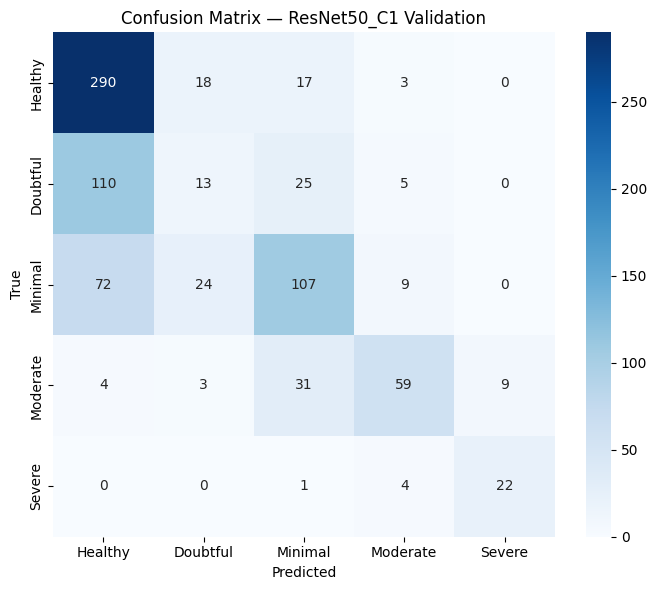

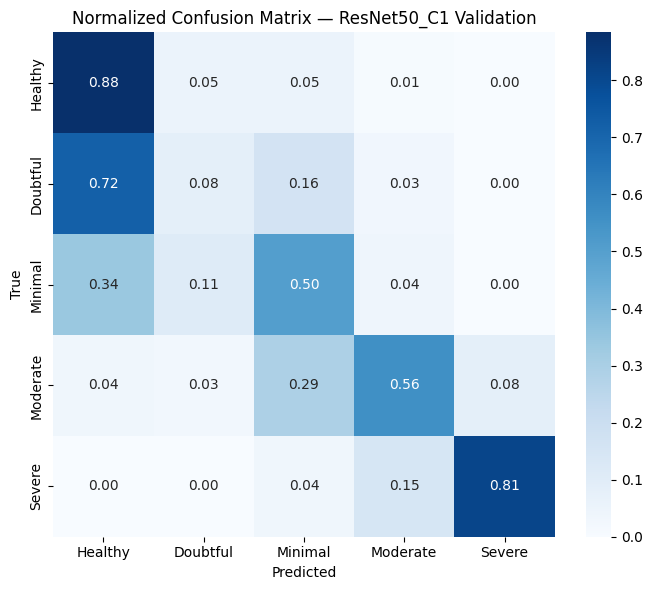

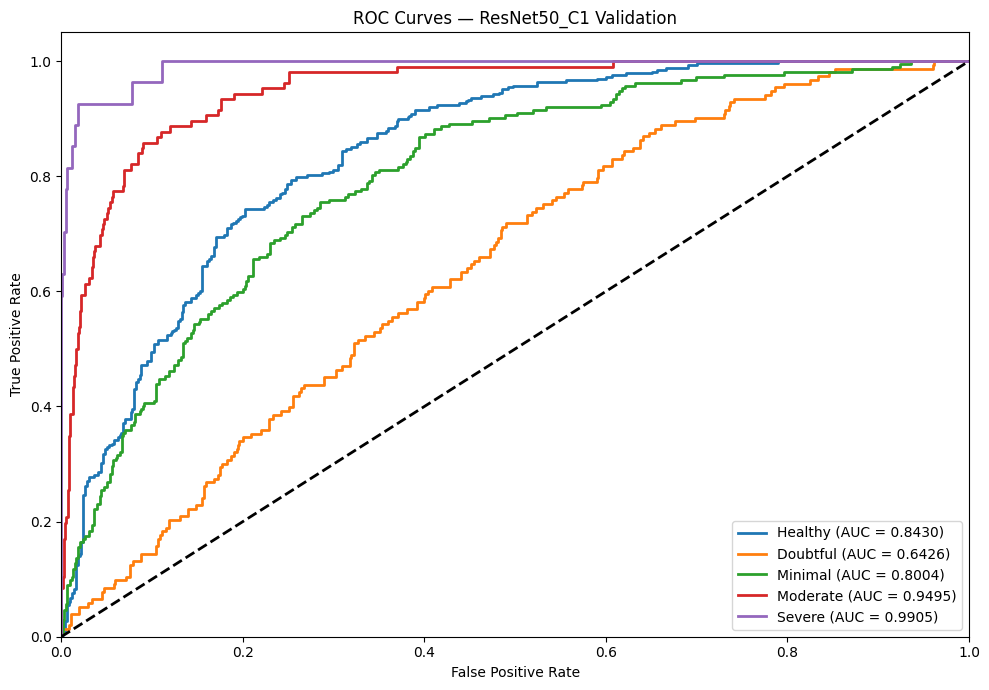

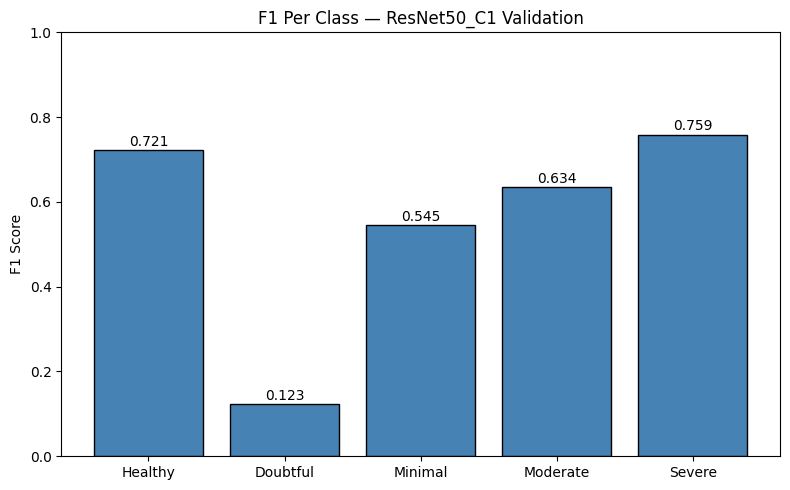

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
valid_generator.reset()
val_probs = best_model.predict(valid_generator, verbose=1)
val_true = valid_generator.labels
val_pred_labels = np.argmax(val_probs, axis=1)

display_full_metrics(val_csv.iloc[0], val_true, val_pred_labels, MODEL_NAME, 'Validation')
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Validation', normalize=True)
plot_roc(val_true, val_probs, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Validation')
plot_f1(val_true, val_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Validation')


## 8. Test Set Evaluation

Reload the best saved model and run the final evaluation on the independent test split.

104/104 [==============================] - 11s 103ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C1
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.6105
  Balanced Accuracy                                0.5806
  Mean Absolute Error (MAE)                        0.5121
  Macro ROC AUC (ordinal matrix)                   0.8581
  Quadratic Weighted Kappa (QWK)                   0.7445

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6139     0.9108     0.7335        639
  Doubtful           0.2673     0.0912     0.1360        296
  Minimal            0.6035     0.5347     0.5670        447
  Moderate           0

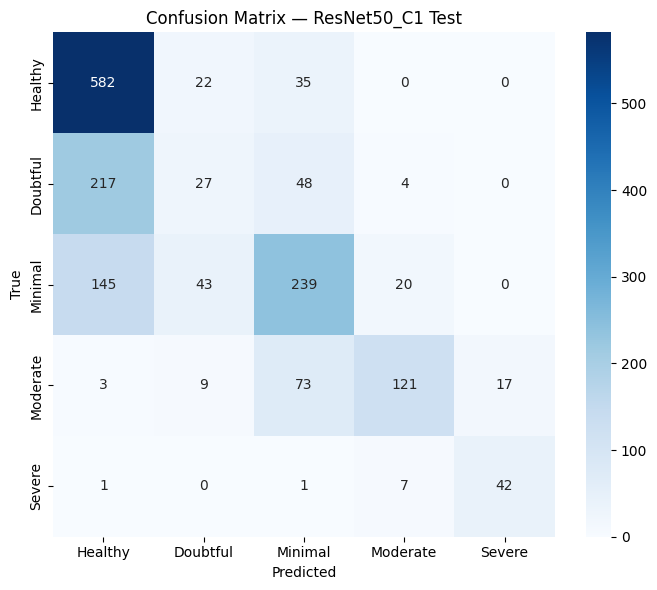

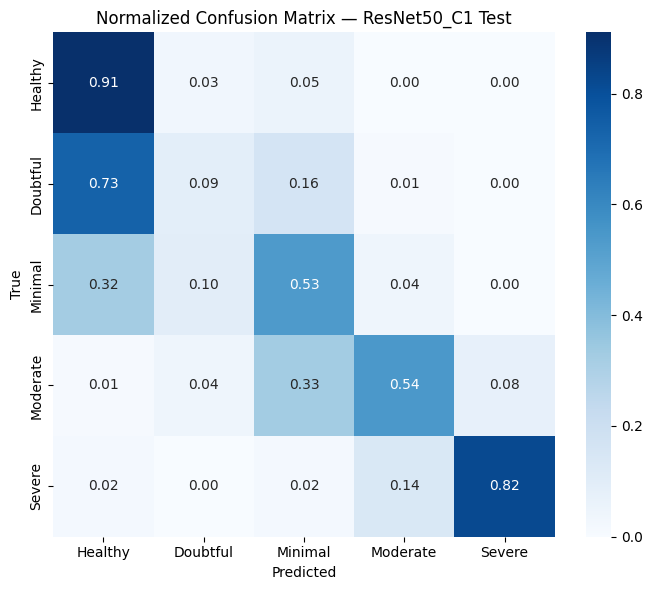

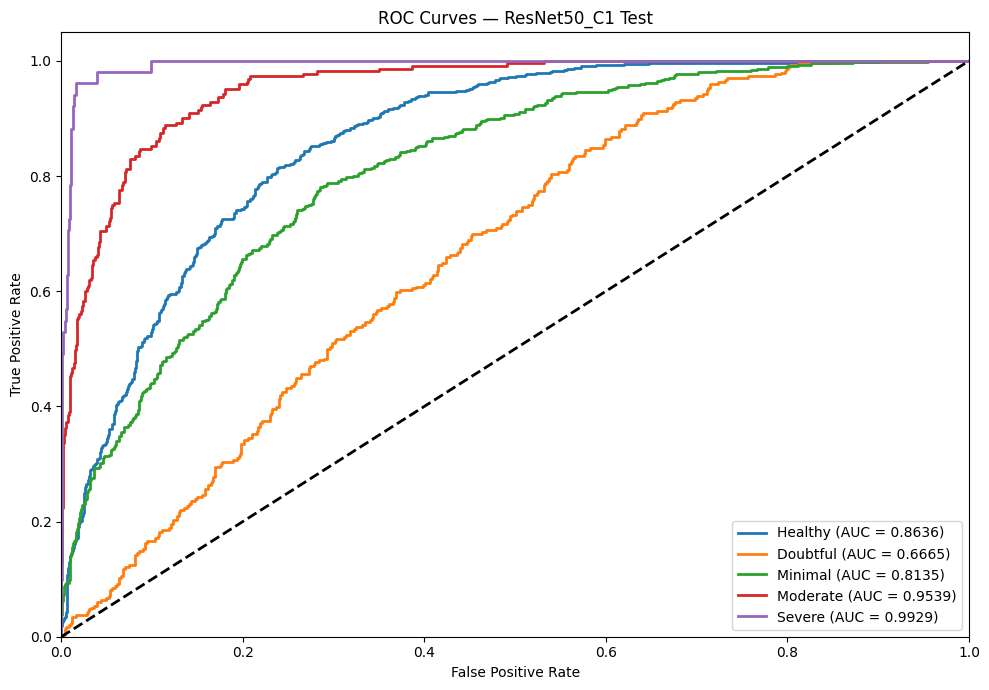

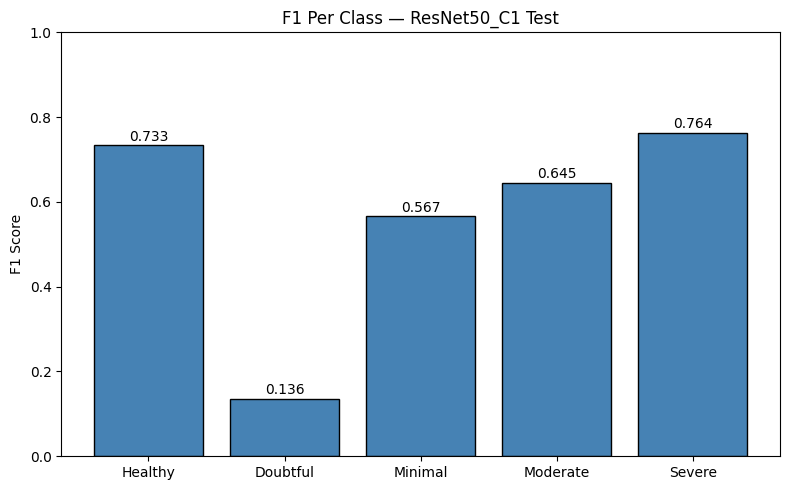

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════
test_generator.reset()
test_probs = best_model.predict(test_generator, verbose=1)
test_true = test_generator.labels
test_pred_labels = np.argmax(test_probs, axis=1)

display_full_metrics(test_csv.iloc[0], test_true, test_pred_labels, MODEL_NAME, 'Test')
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Test', normalize=True)
plot_roc(test_true, test_probs, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Test')
plot_f1(test_true, test_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Test')


## 9. Model Interpretability & Visualization

### GradCAM Functions
These functions generate heatmaps showing which regions of each X-ray the model focuses on when making predictions. This helps validate that the model is identifying clinically relevant features associated with osteoarthritis.

In [ ]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    return superimposed_img

In [33]:
tests_data = get_classes(test_path, class_names, 'test')

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


### Preparing GradCAM
Setting up the gradient model to extract feature map activations from the final convolutional layer before the classification head.

Test data - Healthy


/tmp/ipykernel_2400/3638193015.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


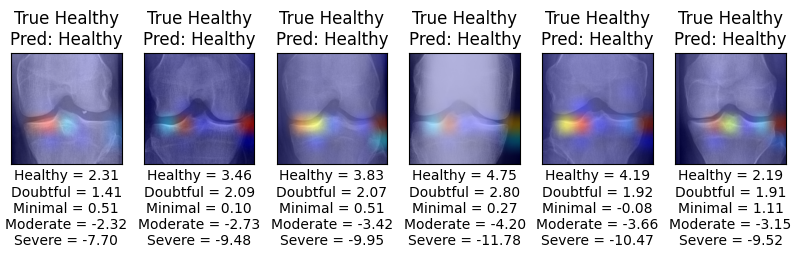

Test data - Doubtful


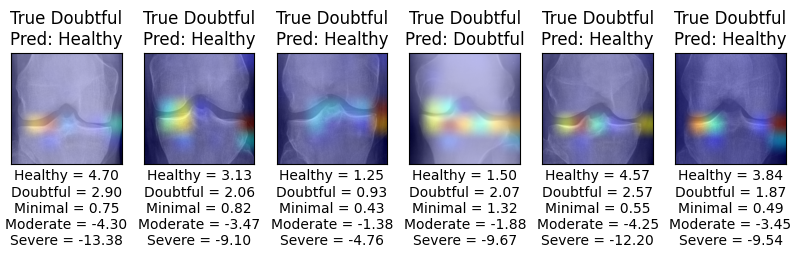

Test data - Minimal


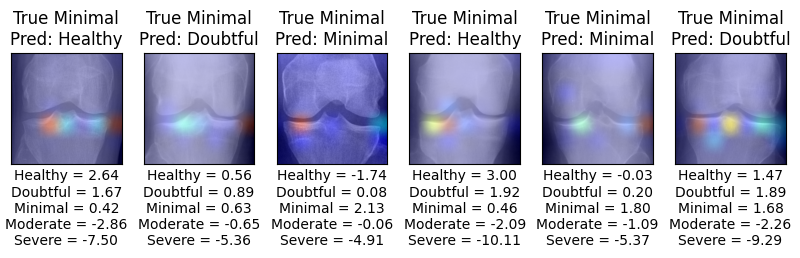

Test data - Moderate


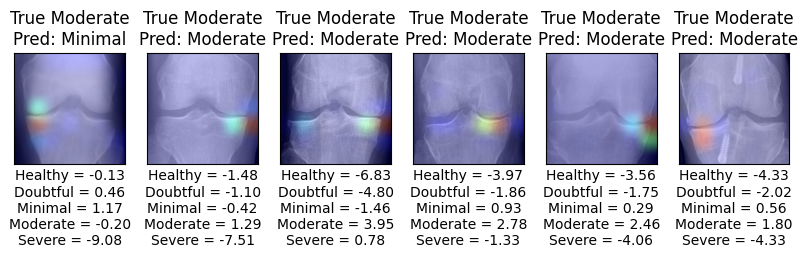

Test data - Severe


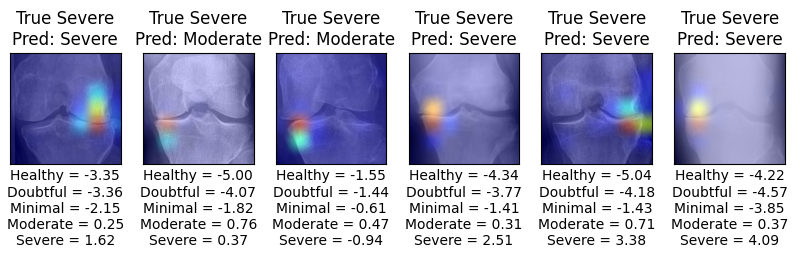

In [ ]:
for k, v in tests_data.items():
    print(f"Test data - {class_names[k]}")
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(test_path, str(k), v[i])
        # prepare image
        img = tf.keras.preprocessing.image.load_img(
            img_path, target_size=target_size
        )
        img = tf.keras.preprocessing.image.img_to_array(img)

        img_aux = img.copy()
        img_array = np.expand_dims(img_aux, axis=0)
        img_array = np.float32(img_array)
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

        y_pred = ResNet50.predict(img_array, verbose=0)[0]

        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)

        plt.subplot(1, 6, 1 + i, xticks=[], yticks=[])
        plt.imshow(image)
        plt.title(
            f"True {class_names[k]}\nPred: {class_names[np.argmax(y_pred)]}"
        )
        plt.xlabel(
            "\n".join([f"{c} = {p:.2f}" for c, p in zip(class_names, y_pred)])
        )
    plt.show()